In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # dari notebooks/ naik ke digital-twin-lite/
assert project_root.name == "digital-twin-lite", f"Root salah: {project_root}"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.generate_data import generate_sensor_log_csv

In [2]:
import os

print(os.getcwd())

C:\Users\LENOVO\digital-twin-lite\notebooks


In [4]:
from pathlib import Path

print(Path("data/raw").exists(), Path("data").exists())

False False


In [6]:
out_path = generate_sensor_log_csv(
    out_relpath="data/raw/sensor_log.csv",
    seed=42,
    make_folders=True
)
out_path

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/raw/sensor_log.csv')

In [7]:
from pathlib import Path

Path("../data/raw/sensor_log.csv").resolve()

WindowsPath('C:/Users/LENOVO/digital-twin-lite/data/raw/sensor_log.csv')

In [8]:
import pandas as pd

df = pd.read_csv(out_path)
df.head()

,t_s,qin_m3s,qout_m3s,u,L_m,Vg_m3,n_mol,P_Pa,n_in_mols,n_out_mols,dP_liq_Pa,L_true_m,P_true_Pa,L_meas_m,P_meas_Pa,L_missing,P_missing
0,0.0,0.000,0.000000,0.00,1.000000,9.000000,400.000000,118243.555556,0.0,0.000000,0.000000,1.000000,118243.555556,1.003047,118097.697316,False,False
1,0.5,0.004,0.002185,0.55,1.000302,8.999093,396.797146,117308.590686,4.0,10.405708,25257.055556,1.000302,117308.590686,0.989903,117434.658699,False,False
2,1.0,0.004,0.002144,0.55,1.000612,8.998165,393.740097,116416.810548,4.0,10.114098,24324.612785,1.000612,116416.810548,1.008116,116386.091536,False,False
3,1.5,0.004,0.002105,0.55,1.000928,8.997217,390.826148,115567.415151,4.0,9.827898,23435.411330,1.000928,115567.415151,1.010333,115372.246065,False,False
4,2.0,0.004,0.002067,0.55,1.001250,8.996251,388.052484,114759.572474,4.0,9.547327,22588.649598,1.001250,114759.572474,0.981739,114557.308736,False,False


In [9]:
df[["L_meas_m", "P_meas_Pa"]].isna().mean()

L_meas_m     0.011657
P_meas_Pa    0.007494
dtype: float64

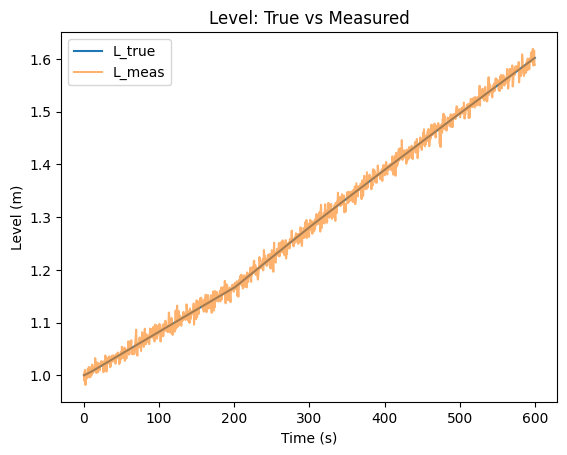

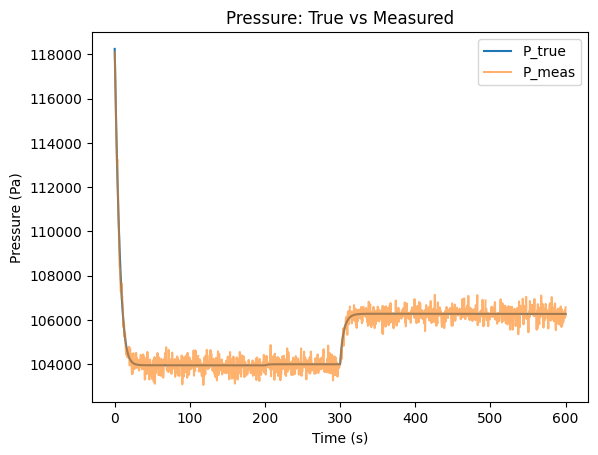

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["t_s"], df["L_true_m"], label="L_true")
plt.plot(df["t_s"], df["L_meas_m"], label="L_meas", alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Level (m)")
plt.title("Level: True vs Measured")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["t_s"], df["P_true_Pa"], label="P_true")
plt.plot(df["t_s"], df["P_meas_Pa"], label="P_meas", alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.title("Pressure: True vs Measured")
plt.legend()
plt.show()